# Plot Surface Data

Generating all Figure could take approximately 1 hour, as the fsnative surface contains a large number of vertices. 

Here we take session 1 as example.

You can use a downsampled fsaverageX surface to speed up plotting, but you would also need to extract the functional beta (and run matlab script) from the GLM folders in NSD.

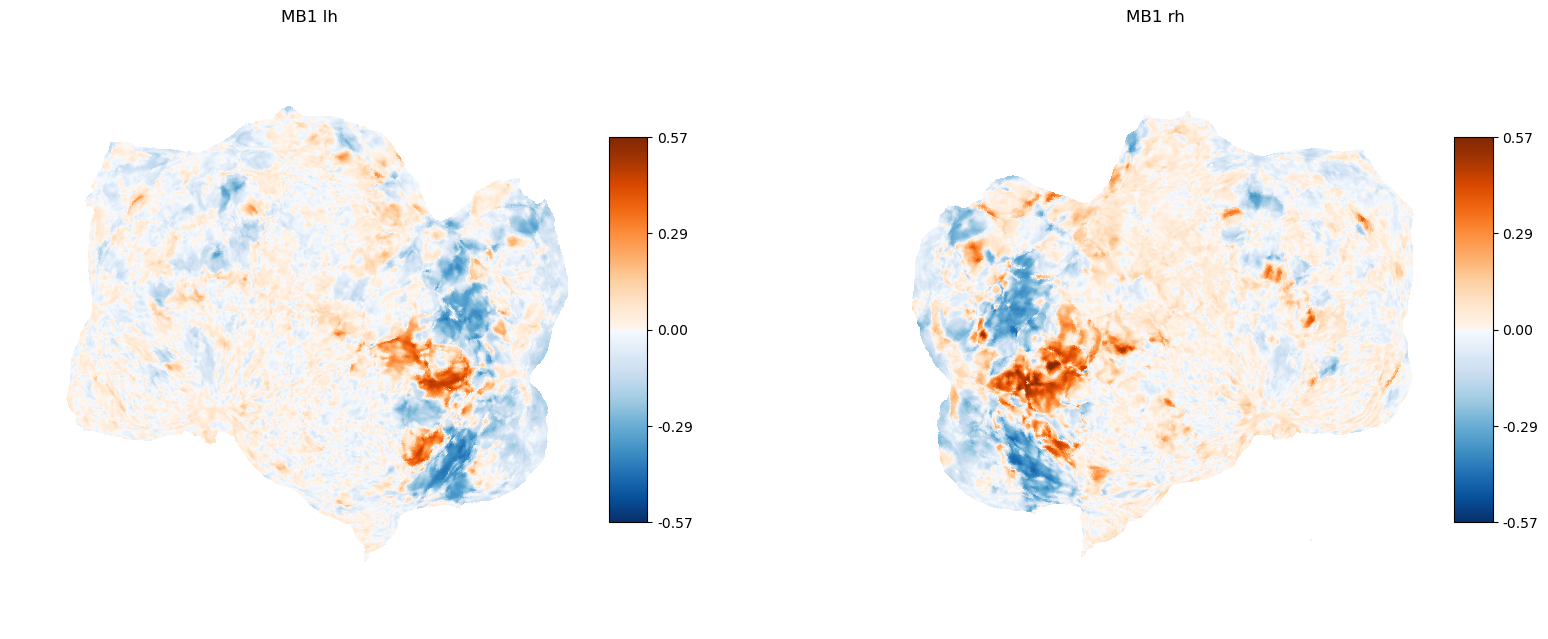

In [2]:
# !pip install pandas numpy scipy matplotlib nilearn
import pandas as pd
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from nilearn import surface, plotting
import nilearn

# generated my favorite colormap and suraface backgound
cmap1 = plt.cm.Blues
cmap2 = plt.cm.Oranges
colors1 = cmap1(np.linspace(0, 1, 256)) 
colors2 = cmap2(np.linspace(0, 1, 256))
subset1 = colors1[::-2]
subset2 = colors2[::2]
new_colors = np.vstack((subset1, subset2))
new_cmap = LinearSegmentedColormap.from_list('custom_cmap', new_colors)
def binarize_curv(curv_data_input):
    curv_data_input = np.sign(curv_data_input)
    curv_data_input[curv_data_input<0]=0.7
    curv_data_input[curv_data_input==1]=1
    curv_output=curv_data_input
    return curv_output

subject_now = '5'
surf_dir = f'./Dataset/RawFromNSD/S{subject_now}/fs/surf' # this is where you download your NSD surface data
file_path = '../exclude_area.xls' # this is where you save your 'others' data
data = pd.read_excel(file_path)
EhpysDataKM = loadmat(f'RDM_S{subject_now}_splits') # this is generated from 'analysis_and_plot_F4a_and_corrmap.m'
hemispheres = ['lh','rh']

for ses_now in range(1): # Just replace this with range(102) for all figures
    fig, axes = plt.subplots(1, 2,subplot_kw={"projection": "3d"},figsize=([20,10]))
    for ax, hemi in zip(axes, hemispheres):
        filename = f'{surf_dir}/flat_{hemi}.gii'
        bg_name = f'{surf_dir}/{hemi}.sulc'

        curv_data = surface.load_surf_data(bg_name)
        curv_data=binarize_curv(curv_data)
        corr_data_to_plot = EhpysDataKM[f'rdm_{hemi}'][ses_now,:]
        d1= np.abs(EhpysDataKM[f'rdm_rh'][ses_now,:]).max()
        d2= np.abs(EhpysDataKM[f'rdm_lh'][ses_now,:]).max()
        vv_max = max(d1,d2)*0.95
        nilearn.plotting.plot_surf_stat_map(filename,
            stat_map = corr_data_to_plot,
            bg_map = curv_data,
            view = 'dorsal',
            avg_method='mean',
            axes=ax,
            cmap=new_cmap,
            vmax=vv_max,
            title=f'{data.iloc[ses_now,3]} {hemi}',
            cbar_tick_format='%.2f',
        )
        current_azim = ax.azim
        ax.view_init(elev=90, azim=current_azim - 90)
    fig.savefig(f'SuarfacePLOT/S{subject_now}_{1+ses_now:03d}_{vv_max:.02f}_{data.iloc[ses_now,3]}.png', dpi=300)

# Plot single-unit data

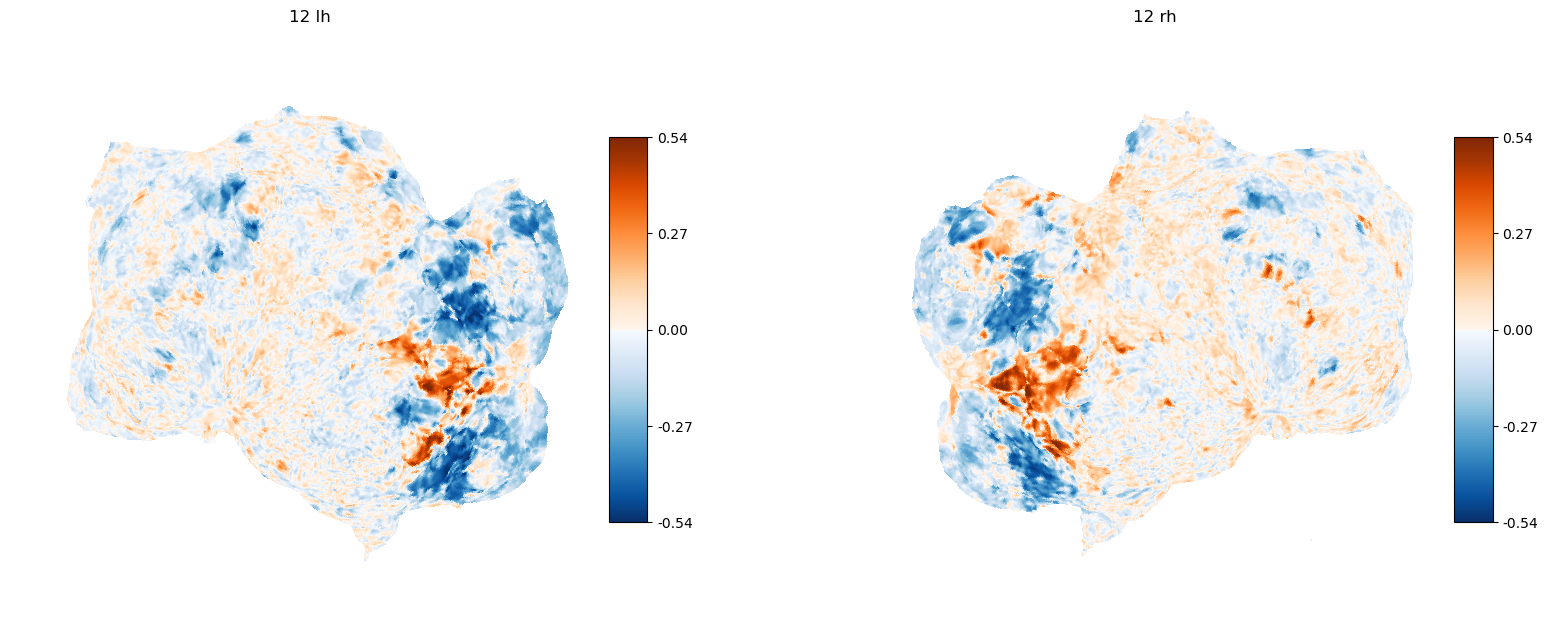

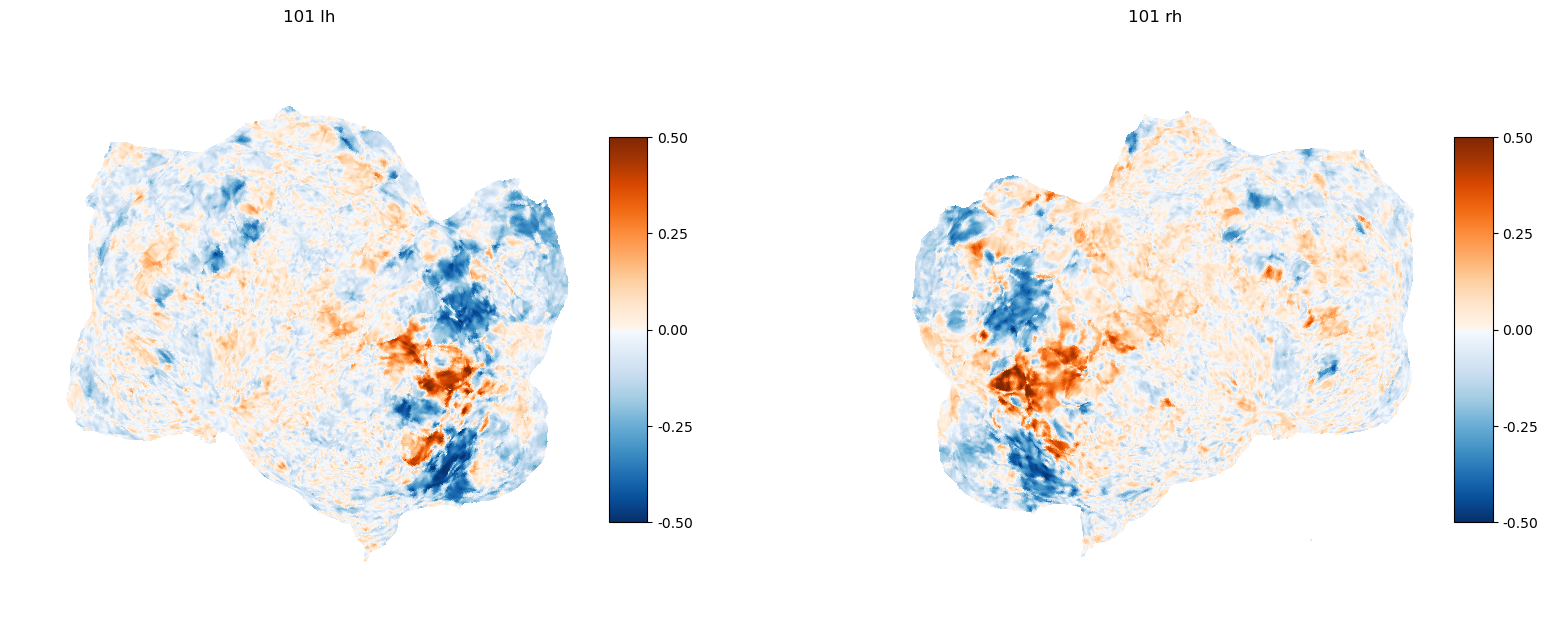

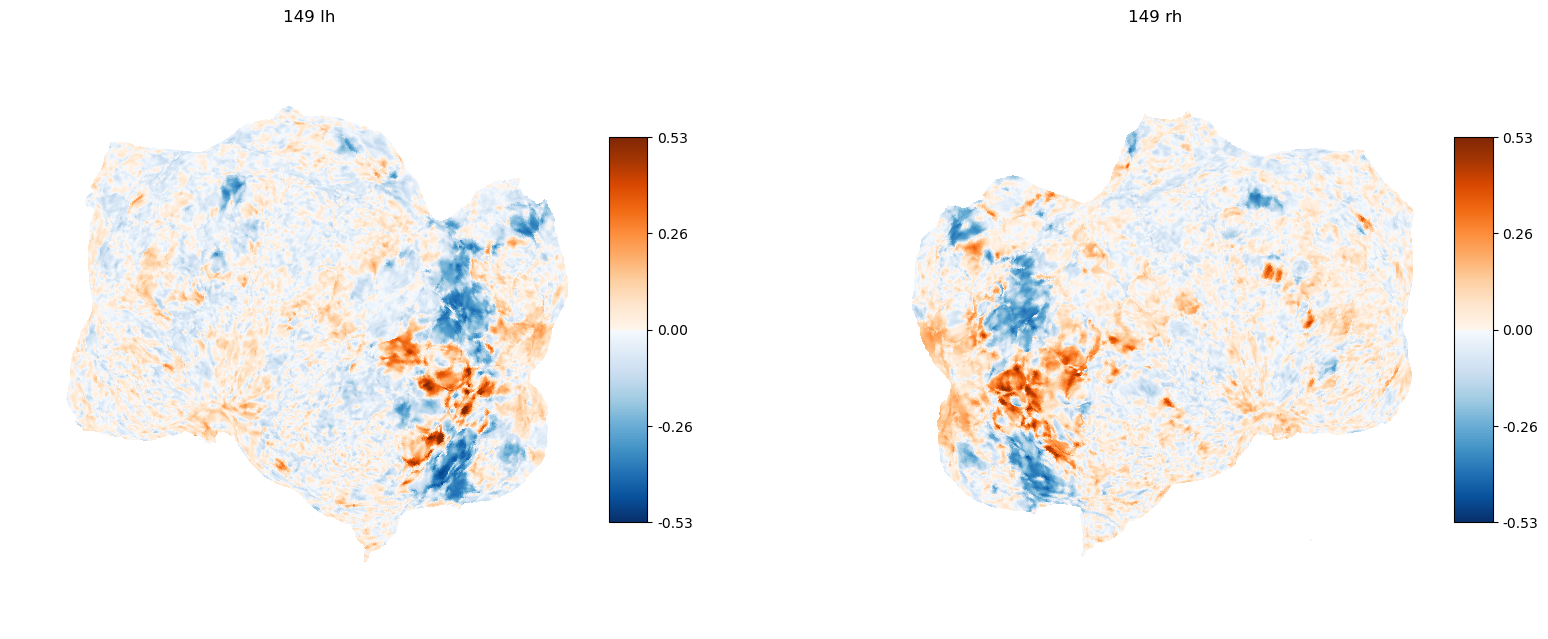

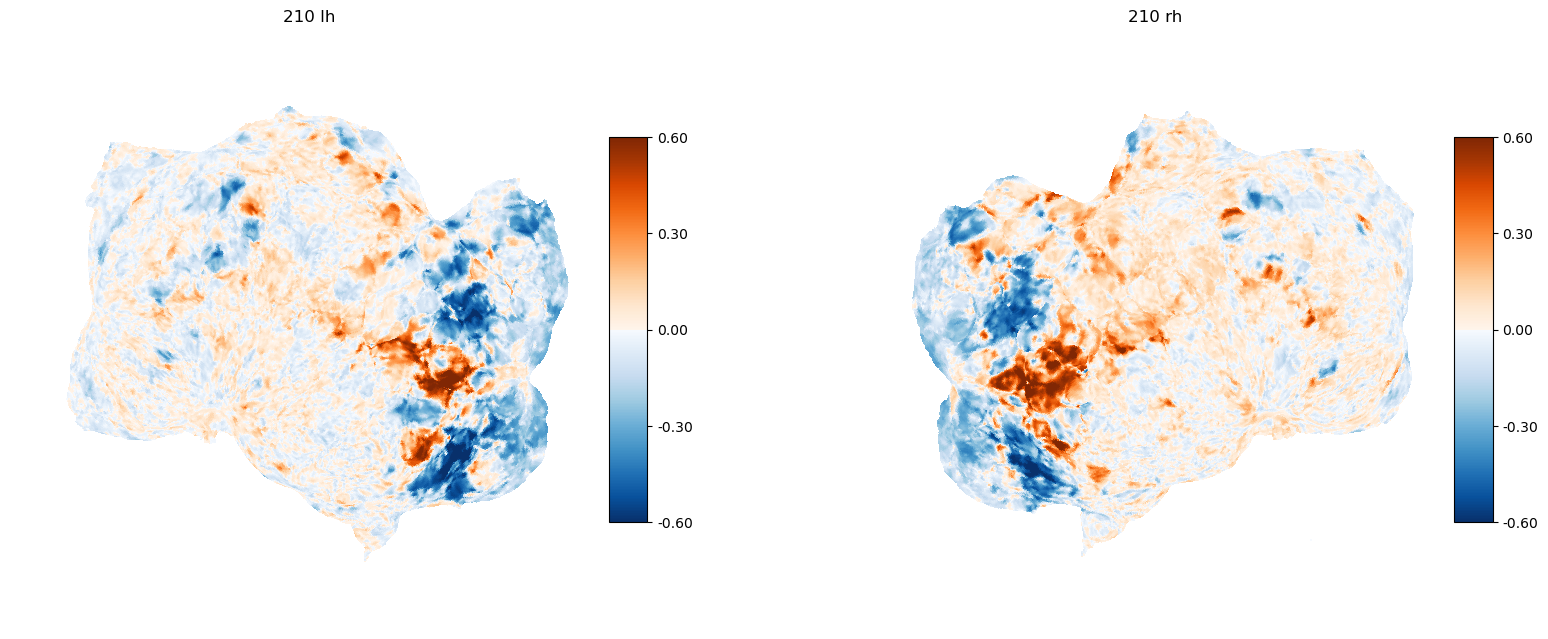

In [5]:
EhpysDataKM = loadmat(f'RDM_MSB_ZZ') # this is generated from ‘S4_show_single_diversity.m’

for unit in [11,100,148,209]: # Here we take 4 example units, replace to range(320) for all units
    fig, axes = plt.subplots(1, 2,subplot_kw={"projection": "3d"},figsize=([20,10]))
    for ax, hemi in zip(axes, hemispheres):
        filename = f'{surf_dir}/flat_{hemi}.gii'
        bg_name = f'{surf_dir}/{hemi}.sulc'
        curv_data = surface.load_surf_data(bg_name)
        curv_data=binarize_curv(curv_data)
        corr_data_to_plot = EhpysDataKM[f'rdm_{hemi}'][unit,:].reshape(1, curv_data.shape[0])
        d1= np.abs(EhpysDataKM[f'rdm_rh'][unit,:]).max()
        d2= np.abs(EhpysDataKM[f'rdm_lh'][unit,:]).max()
        vv_max = max(d1,d2)*0.8
        nilearn.plotting.plot_surf_stat_map(filename,
            stat_map = corr_data_to_plot,
            bg_map = curv_data,
            view = 'dorsal',
            avg_method='mean',
            axes=ax,
            cmap=new_cmap,
            vmax=vv_max,
            title=f'{unit+1} {hemi}',
            cbar_tick_format='%.2f',
        )
        current_azim = ax.azim
        ax.view_init(elev=90, azim=current_azim - 90)
    fig.savefig(f'SingleSurfacePlot/S{subject_now}_{1+unit:03d}_{vv_max:.02f}.png', dpi=300)